# Problem A: Recover Young's modulus in 1D Elastostatics
Consider a rod made of linearly elastic material subjected to some load. Static problems will be considered here, by which is meant it is not necessary to know how the load was applied, or how the material particles moved to reach the stressed state; it is necessary only that the load is applied slowly enough so that the accelerations are zero, or that it was applied sufficiently long ago that any vibrations have died away and movement has ceased. 

The equation governing the static response of the rod is: 
$$
-\frac{d}{dx} \left( k(x) \frac{du}{dx} \right) = f, \quad x \in (0, L) \tag{1}
$$
where
- $u(x):$ displacement field of the rod
- $k(x):$ Young’s modulus 
- $f=9.81:$ body force per unit length (e.g., gravity)
- $L=1.:$ Length of the rod

We consider the fixation of both sides of the rod, which leads to the following boundary conditions:
- $u(0) = u(L) = 0$

## Task: Recover the Young's modulus $k(x)$ from the observation of displacement field $u(x)$
In this task, the Young's modulus $k(x)>0$ of the rod is unknown. However, we observe the displacement field $u_{obs}$ (contaminated by noise with noise level $\sim 5\%$) on a set of randomly placed sensors $x_{obs}$ (with size $N_{obs}=500$).

### The goals
- Please select a suitable deep learning method for solving this inverse problem to recover the Young's modulus $k(x)$, and explain the reason for using it
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on testing dataset) at each training epoch and plot the ```Error vs. epoch``` curve (and report the final error). The $L^2$ relative error between the prediction $k_{pred} (or\ u_{pred})$ and the truth $k_{true} (or\ u_{true})$ is defined as follows:
  $$error = \sqrt{\frac{\sum^{n}_i|k_{pred}(x_i)-k_{true}(x_i)|^2}{\sum^{n}_{i}|k_{true}(x_i)|^2}}$$
- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with ```matplotlib```.
  
### Dataset
The observation and the ground truth references are given in the dataset ```ProblemA_dataset.h5```:
- ```x_obs```: the observation sensors 
- ```u_obs```: the observed displacement field $u$ (contaminated by noise)
- ```x_test```: the locations where the ground truth is evaluated (Used for computing error and should **not** be used for training)
- ```k_test```: the ground truth reference for Young's modulus (Used for computing error and should **not** be used for training)
- ```u_test```: the ground truth reference for displacement field (Used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

In [67]:
import os
num_cores = os.cpu_count()
recommended_workers = min(20,num_cores)

print(num_cores)
print(recommended_workers)

16
16


In [68]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch.autograd import grad, Variable
from torch.utils.data import Dataset, DataLoader
from tqdm import trange
device = ("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [69]:
import multiprocessing as mp
try:
    mp.set_start_method('spawn', force=True) 
except RuntimeError:
    pass

<KeysViewHDF5 ['k_test', 'u_obs', 'u_test', 'x_obs', 'x_test']>


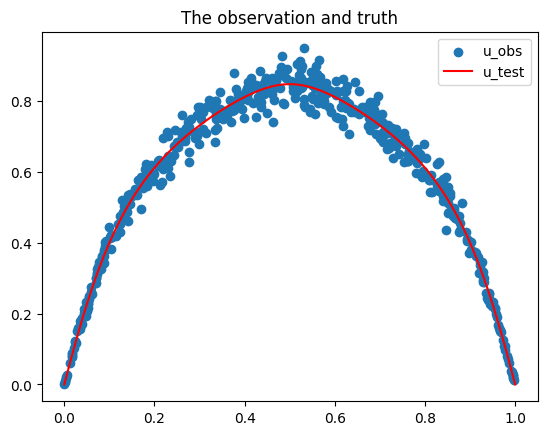

In [70]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
#
with h5py.File('ProblemA_dataset.h5', 'r') as file:
    print(file.keys())
    #
    x_obs = np.array(file['x_obs']).reshape(-1,1)
    u_obs = np.array(file['u_obs']).reshape(-1,1)
    x_test = np.array(file['x_test']).reshape(-1,1)
    k_test = np.array(file['k_test']).reshape(-1,1)
    u_test = np.array(file['u_test']).reshape(-1,1)
#
plt.figure()
plt.scatter(x_obs, u_obs, label='u_obs')
plt.plot(x_test, u_test,color='red', label="u_test")
plt.title('The observation and truth')
plt.legend()
plt.show()

In [71]:
#print(x_obs) # input for my NN (500,1)
print(x_obs.shape)
#print(u_obs) # output of my NN (500,1)
print(u_obs.shape)
print(x_test.shape)
print(k_test.shape)
print(u_test.shape)
L = 1.0
f = 9.81

(500, 1)
(500, 1)
(10001, 1)
(10001, 1)
(10001, 1)


In [72]:
x_obs = torch.tensor(x_obs, dtype=torch.float32).view(-1,1).to(device=device)
u_obs = torch.tensor(u_obs, dtype=torch.float32).view(-1,1).to(device=device)
x_test = torch.tensor(x_test, dtype=torch.float32).view(-1,1).to(device=device)
u_test = torch.tensor(u_test, dtype=torch.float32).view(-1,1).to(device=device)
k_test = torch.tensor(k_test, dtype=torch.float32).view(-1,1).to(device=device)
print(k_test)
print(u_test)
print(x_test)
print(x_obs.shape)
print(u_obs.shape)
print(x_test.shape)
print(k_test.shape)
print(u_test.shape)

x_bd = torch.tensor([[0.0],[1.0]], dtype=torch.float32).to(device=device)
u_bd = torch.tensor([[0.0],[0.0]], dtype=torch.float32).to(device=device)
f=9.18
L=1.0


tensor([[1.0000],
        [1.0000],
        [1.0000],
        ...,
        [1.0000],
        [1.0000],
        [1.0000]], device='cuda:0')
tensor([[0.0000],
        [0.0005],
        [0.0010],
        ...,
        [0.0010],
        [0.0005],
        [0.0000]], device='cuda:0')
tensor([[0.0000e+00],
        [1.0000e-04],
        [2.0000e-04],
        ...,
        [9.9980e-01],
        [9.9990e-01],
        [1.0000e+00]], device='cuda:0')
torch.Size([500, 1])
torch.Size([500, 1])
torch.Size([10001, 1])
torch.Size([10001, 1])
torch.Size([10001, 1])


In [73]:
pip install torch-summary

Note: you may need to restart the kernel to use updated packages.


In [74]:

class RecoverYoungPINN(nn.Module):
    def __init__(self):
        super(RecoverYoungPINN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(1,128),
            nn.SiLU(),
            nn.Linear(128,128),
            nn.SiLU(),
            nn.Linear(128,128),
            nn.SiLU(),
            nn.Linear(128,128),
            nn.SiLU(),
            nn.Linear(128,2))

    def forward(self,x):
        output = self.network(x)
        u = output[:,0:1]
        k = output[:,1:2]

        k = torch.nn.functional.softplus(k)

        return u,k

reverse_model = RecoverYoungPINN().to(device)
summary(reverse_model, device=device)

       

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       256
|    └─SiLU: 2-2                         --
|    └─Linear: 2-3                       16,512
|    └─SiLU: 2-4                         --
|    └─Linear: 2-5                       16,512
|    └─SiLU: 2-6                         --
|    └─Linear: 2-7                       16,512
|    └─SiLU: 2-8                         --
|    └─Linear: 2-9                       258
Total params: 50,050
Trainable params: 50,050
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       256
|    └─SiLU: 2-2                         --
|    └─Linear: 2-3                       16,512
|    └─SiLU: 2-4                         --
|    └─Linear: 2-5                       16,512
|    └─SiLU: 2-6                         --
|    └─Linear: 2-7                       16,512
|    └─SiLU: 2-8                         --
|    └─Linear: 2-9                       258
Total params: 50,050
Trainable params: 50,050
Non-trainable params: 0

In [75]:
class LossClass(object):
    def __init__(self, model):
        self.device = device
        self.model = model
        self.getLoss = nn.MSELoss()
        
    def loss_data(self,x_obs,u_obs):
        x_obs=x_obs.to(self.device)
        u_obs=u_obs.to(self.device)

        u_pred,_ = self.model(x_obs)
        loss = self.getLoss(u_pred, u_obs)
        return loss

    def loss_bd(self, x_bd, u_bd):
        x_bd = x_bd.to(self.device)
        u, _ = self.model(x_bd)
        loss = self.getLoss(u,u_bd.to(self.device))
        return loss

    def loss_pde(self, x_in):
        x = Variable(x_in, requires_grad=True).to(self.device)
        u,k = self.model(x)
        du_dx = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u),create_graph=True)[0]
        s = k*du_dx
        ds_dx = grad(inputs=x, outputs=s, grad_outputs=torch.ones_like(s),create_graph=True)[0]
        residual = -ds_dx -f
        loss = self.getLoss(residual, torch.zeros_like(residual))
        return loss

    def get_error(self, x_test,u_test,k_test):
        x_test = x_test.to(self.device)
        u_pred, k_pred = self.model(x_test)
        u_numi = torch.sum((u_pred-u_test.to(self.device))**2)
        u_domi = torch.sum(u_test.to(self.device)**2)
        k_numi = torch.sum((k_pred-k_test.to(self.device))**2)
        k_domi = torch.sum(k_test.to(self.device)**2)
        u_error = torch.sqrt(u_numi/u_domi)
        k_error = torch.sqrt(k_numi/k_domi)

        return u_error, k_error

    

In [76]:
from pinn_dataset import MyDataset

In [81]:
x_in = torch.linspace(0.0,1.0,6000).view(-1,1).to(device=device)
#dataloader = DataLoader(MyDataset(x_in), batch_size=500, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
epochs = 9000
batch_size = 200
lr=0.001
optimizer = torch.optim.Adam(params=reverse_model.parameters(), lr=lr, weight_decay=1e-4)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=int(epochs/5),gamma=0.5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=100)
w_data= 500
w_bd= 100
w_pde= 10
u_error_list=[]
k_error_list=[]

In [82]:
print("Starting training..")
for epochs in trange(epochs):
        
    perm = torch.randperm(x_in.size(0))

    for i in range(0,x_in.size(0), batch_size):

        indices = perm[i:i+batch_size]
        x_batch = x_in[indices]
        lossClass = LossClass(reverse_model)
        data_loss = lossClass.loss_data(x_obs,u_obs)
        boundary_loss = lossClass.loss_bd(x_bd, u_bd)
        pde_loss = lossClass.loss_pde(x_batch)

        total_loss = w_data*data_loss + w_bd*boundary_loss + w_pde*pde_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

    with torch.no_grad():
        u_err, k_err = lossClass.get_error(x_test, u_test, k_test)
        k_error_list.append(k_err.item())
        u_error_list.append(u_err.item())

    scheduler.step(total_loss)

    if (epochs + 1) % 500 == 0 :
        current_lr = scheduler.optimizer.param_groups[0]["lr"]
        print(f"\nEpoch: {epochs+1:4d} | Training Loss: {total_loss.item():.4f} | Displacement L^2 error: {u_err.item():.4f} |Young Modulus L^2 error: {k_err.item():.4f} | LR: {current_lr:.6f}")

Starting training..


  6%|▌         | 500/9000 [02:31<44:12,  3.20it/s]


Epoch:  500 | Training Loss: 0.4416 | Displacement L^2 error: 0.0055 |Young Modulus L^2 error: 0.1180 | LR: 0.000125


 11%|█         | 1000/9000 [05:22<45:31,  2.93it/s]


Epoch: 1000 | Training Loss: 0.4376 | Displacement L^2 error: 0.0043 |Young Modulus L^2 error: 0.0976 | LR: 0.000125


...


Epoch: 8000 | Training Loss: 0.4318 | Displacement L^2 error: 0.0034 |Young Modulus L^2 error: 0.0792 | LR: 0.000000


 94%|█████████▍| 8500/9000 [1:00:09<04:29,  1.85it/s]


Epoch: 8500 | Training Loss: 0.4318 | Displacement L^2 error: 0.0034 |Young Modulus L^2 error: 0.0792 | LR: 0.000000


100%|██████████| 9000/9000 [1:04:04<00:00,  2.34it/s]


Epoch: 9000 | Training Loss: 0.4318 | Displacement L^2 error: 0.0034 |Young Modulus L^2 error: 0.0792 | LR: 0.000000


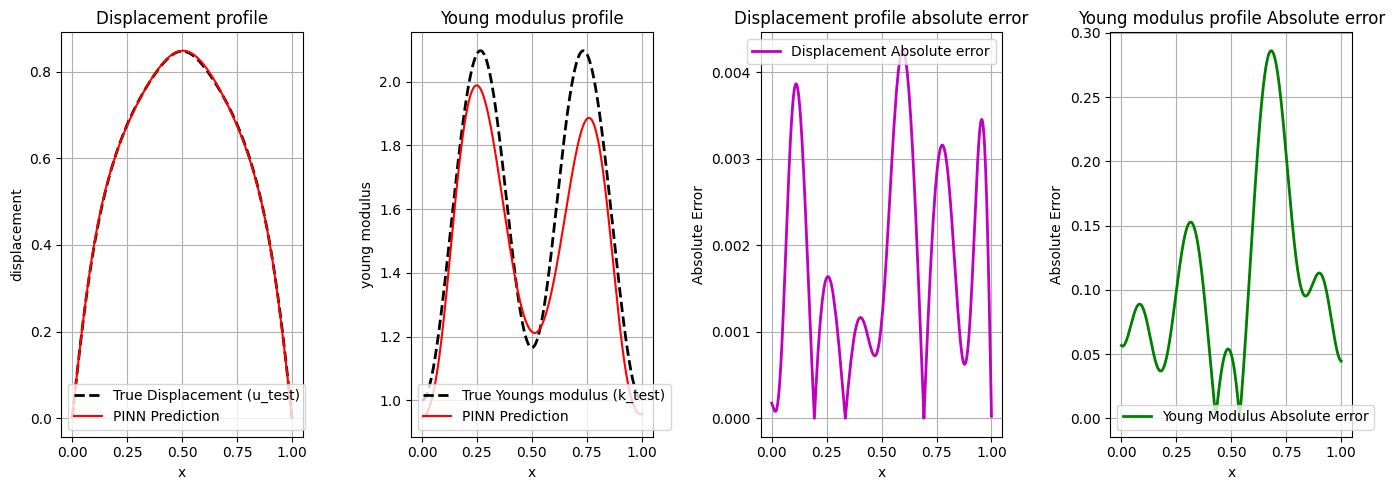

In [83]:
def plot_results(x_test, u_test,K_test, reverse_model):
    reverse_model.eval()
    with torch.no_grad():
        u_pred, k_pred = reverse_model(x_test.to(device))
        x = x_test.cpu().numpy()
        u_true = u_test.detach().cpu().numpy()
        k_true = k_test.detach().cpu().numpy()

        u_pred = u_pred.cpu().numpy()
        k_pred = k_pred.cpu().numpy()

    u_abs_error = np.abs(u_pred-u_true)
    k_abs_error = np.abs(k_pred-k_true)

    fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4, figsize=(14,5))

    ax1.plot(x,u_true, 'k--', label="True Displacement (u_test)", linewidth=2)
    ax1.plot(x,u_pred, 'r-', label="PINN Prediction")
    ax1.set_title("Displacement profile")
    ax1.set_xlabel("x")
    ax1.set_ylabel("displacement")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(x,k_true, 'k--', label="True Youngs modulus (k_test)", linewidth=2)
    ax2.plot(x,k_pred, 'r-', label="PINN Prediction")
    ax2.set_title("Young modulus profile")
    ax2.set_xlabel("x")
    ax2.set_ylabel("young modulus")
    ax2.legend()
    ax2.grid(True)

    ax3.plot(x,u_abs_error, 'm-', label="Displacement Absolute error", linewidth=2)
  
    ax3.set_title("Displacement profile absolute error")
    ax3.set_xlabel("x")
    ax3.set_ylabel("Absolute Error")
    ax3.legend()
    ax3.grid(True)

    ax4.plot(x,k_abs_error, 'g-', label="Young Modulus Absolute error", linewidth=2)
    ax4.set_title("Young modulus profile Absolute error")
    ax4.set_xlabel("x")
    ax4.set_ylabel("Absolute Error")
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    plt.show()
    fig.savefig("C:\SOURAV\DL_PDE_PROJECT\Recover young's modulus in 1D Elastostatics\Results\Plot_11.png")

plot_results(x_test,u_test,k_test, reverse_model)